# Car Dataset - Complete EDA

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_csv("car_data.csv")

## 3. Data Inspection
   - Shape
   - Head / Tail
   - Info
   - Data Types
   - Describe
   - Missing Values
   - Duplicates
   - Unique Values

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007.0,NaN,70000.0,Petrrol,NaN,Manual,First Owner
1,Maruti Wagon R LXI Minor,NaN,135000.0,50000.0,Petorl,Indvidual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012.0,600000.0,100000.0,Deisel,Indvidual,Manual,First Owner
3,Datsun RediGO T Option,2017.0,250000.0,46000.0,Petorl,Indivudal,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Diesl,Indivudal,Manual,Second Owner


In [4]:
df.shape

(4345, 8)

In [5]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4340,NaN,2010.0,165000.0,80000.0,NaN,Indvidual,Manual,First Owner
4341,Renault KWID RXT BSIV,2019.0,250000.0,27000.0,NaN,Indvidual,Manual,First Owner
4342,Hyundai Santro Xing GL Plus,2008.0,120000.0,41723.0,Petorl,Indvidual,Manual,Second Owner
4343,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Deisel,Indvidual,Manual,Second Owner
4344,Mahindra TUV 300 T8 AMT,2016.0,730000.0,60000.0,Diesl,Indivudal,Automatic,Second Owner


In [6]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')

In [7]:
df.dtypes

name                 str
year             float64
selling_price    float64
km_driven            str
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4017 non-null   str    
 1   year           4041 non-null   float64
 2   selling_price  4054 non-null   float64
 3   km_driven      4026 non-null   str    
 4   fuel           4042 non-null   str    
 5   seller_type    4056 non-null   str    
 6   transmission   4040 non-null   str    
 7   owner          4059 non-null   str    
dtypes: float64(2), str(6)
memory usage: 271.7 KB


In [9]:
df.describe()

,year,selling_price
count,4041.000000,4.054000e+03
mean,2013.276417,5.026554e+05
std,16.556865,5.804930e+05
min,1800.000000,-1.200000e+05
25%,2011.000000,2.000000e+05
50%,2014.000000,3.500000e+05
75%,2016.000000,6.000000e+05
max,3000.000000,8.900000e+06


In [10]:
df.describe(include="all")

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
count,4017,4041.000000,4.054000e+03,4026,4042,4056,4040,4059
unique,1438,NaN,NaN,743,8,5,2,5
top,Maruti Swift Dzire VDI,NaN,NaN,70000.0,Diesl,Indivudal,Manual,First Owner
freq,67,NaN,NaN,224,1013,1531,3611,2654
mean,NaN,2013.276417,5.026554e+05,NaN,NaN,NaN,NaN,NaN
std,NaN,16.556865,5.804930e+05,NaN,NaN,NaN,NaN,NaN
min,NaN,1800.000000,-1.200000e+05,NaN,NaN,NaN,NaN,NaN
25%,NaN,2011.000000,2.000000e+05,NaN,NaN,NaN,NaN,NaN
50%,NaN,2014.000000,3.500000e+05,NaN,NaN,NaN,NaN,NaN
75%,NaN,2016.000000,6.000000e+05,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

name             328
year             304
selling_price    291
km_driven        319
fuel             303
seller_type      289
transmission     305
owner            286
dtype: int64

In [12]:
missing_percentage = df.isnull().mean() * 100

missing_percentage.sort_values(ascending=False)

name             7.548907
km_driven        7.341772
transmission     7.019563
year             6.996548
fuel             6.973533
selling_price    6.697353
seller_type      6.651323
owner            6.582278
dtype: float64

In [13]:
df.duplicated().sum()

np.int64(112)

In [14]:
for column in df.columns:
    print(column, ":", df[column].nunique())

name : 1438
year : 31
selling_price : 435
km_driven : 743
fuel : 8
seller_type : 5
transmission : 2
owner : 5


In [15]:
print(df["fuel"].value_counts())
print(df["seller_type"].value_counts())
print(df["transmission"].value_counts())
print(df["owner"].value_counts())

fuel
Diesl       1013
Deisel       987
Petrrol      682
Petrl        677
Petorl       619
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Indivudal           1531
Indvidual           1503
Deelar               476
Dealerr              452
Trustmark Dealer      94
Name: count, dtype: int64
transmission
Manual       3611
Automatic     429
Name: count, dtype: int64
owner
First Owner             2654
Second Owner            1035
Third Owner              280
Fourth & Above Owner      73
Test Drive Car            17
Name: count, dtype: int64


## 4. Data Cleaning
   - Handle Missing Values
   - Convert km_driven
   - Remove Duplicates
   - Validate Data

In [16]:
df_clean = df.copy()

In [17]:
df_clean.isnull().sum()

name             328
year             304
selling_price    291
km_driven        319
fuel             303
seller_type      289
transmission     305
owner            286
dtype: int64

In [18]:
df_clean["year"] = df_clean["year"].fillna(df_clean["year"].median())

df_clean["selling_price"] = df_clean["selling_price"].fillna(
    df_clean["selling_price"].median()
)

In [19]:
categorical_columns = [
    "name",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].mode()[0]
    )

In [20]:
df_clean["km_driven"].head(10)

0     70000.0
1     50000.0
2    100000.0
3     46000.0
4    141000.0
5         NaN
6         NaN
7     60000.0
8     25000.0
9     78000.0
Name: km_driven, dtype: str

In [21]:
df_clean["km_driven"] = pd.to_numeric(
    df_clean["km_driven"],
    errors="coerce"
)

In [22]:
df_clean["km_driven"] = df_clean["km_driven"].fillna(
    df_clean["km_driven"].median()
)

In [23]:
df_clean.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [24]:
df_clean = df_clean.drop_duplicates()

In [25]:
# Fix invalid years
df_clean.loc[
    ~df_clean["year"].between(1990, 2026),
    "year"
] = np.nan

df_clean["year"] = df_clean["year"].fillna(
    df_clean["year"].median()
)

In [26]:
# Remove invalid selling prices
df_clean = df_clean[df_clean["selling_price"] >= 0]

In [27]:
# Standardize categorical values

df_clean["fuel"] = df_clean["fuel"].replace({
    "Petrrol": "Petrol",
    "Petorl": "Petrol",
    "Petrl": "Petrol",
    "Diesl": "Diesel",
    "Deisel": "Diesel"
})

df_clean["seller_type"] = df_clean["seller_type"].replace({
    "Indvidual": "Individual",
    "Indivudal": "Individual",
    "Deelar": "Dealer",
    "Dealerr": "Dealer"
})

In [28]:
df_clean.duplicated().sum()

np.int64(267)

In [29]:
df_clean.dtypes

name                 str
year             float64
selling_price    float64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object

In [30]:
df_clean["year"].describe()

count    4188.000000
mean     2013.126074
std         4.092594
min      1992.000000
25%      2011.000000
50%      2014.000000
75%      2016.000000
max      2020.000000
Name: year, dtype: float64

In [31]:
df_clean["year"].unique()

array([2007., 2014., 2012., 2017., 2016., 2015., 2018., 2019., 2013.,
       2011., 2010., 2009., 1996., 2005., 2006., 2008., 2004., 1998.,
       2003., 2002., 2020., 2000., 2001., 1995., 1999., 1997., 1992.])

In [32]:
df_clean["selling_price"].describe()

count    4.188000e+03
mean     4.781604e+05
std      5.273964e+05
min      2.000000e+04
25%      2.110000e+05
50%      3.500000e+05
75%      5.750000e+05
max      8.900000e+06
Name: selling_price, dtype: float64

In [33]:
(df_clean["selling_price"] < 0).sum()

np.int64(0)

In [34]:
df_clean["km_driven"].describe()

count    4.188000e+03
mean     8.626859e+04
std      8.300825e+05
min      1.000000e+00
25%      3.800000e+04
50%      6.000000e+04
75%      9.000000e+04
max      5.000000e+07
Name: km_driven, dtype: float64

In [35]:
(df_clean["km_driven"] < 0).sum()

np.int64(0)

## 5. Feature Engineering
   - Car Age
   - Brand
   - Price in Lakhs
   - KM in Thousands

In [36]:
df_clean["car_age"] = 2026 - df_clean["year"]

In [37]:
df_clean[["year", "car_age"]].head()

,year,car_age
0,2007.0,19.0
1,2014.0,12.0
2,2012.0,14.0
3,2017.0,9.0
4,2014.0,12.0


In [38]:
df_clean["brand"] = df_clean["name"].str.split().str[0]

In [39]:
df_clean[["name", "brand"]].head(20)

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda
5,Maruti Alto LX BSIII,Maruti
6,Maruti Swift Dzire VDI,Maruti
7,Tata Indigo Grand Petrol,Tata
8,Hyundai Creta 1.6 VTVT S,Hyundai
9,Maruti Celerio Green VXI,Maruti


In [40]:
df_clean["selling_price_lakh"] = df_clean["selling_price"] / 100000

In [41]:
df_clean["km_driven_thousand"] = df_clean["km_driven"] / 1000

In [42]:
df_clean.head(20)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand,selling_price_lakh,km_driven_thousand
0,Maruti 800 AC,2007.0,350000.0,70000.0,Petrol,Individual,Manual,First Owner,19.0,Maruti,3.50,70.0
1,Maruti Wagon R LXI Minor,2014.0,135000.0,50000.0,Petrol,Individual,Manual,First Owner,12.0,Maruti,1.35,50.0
2,Hyundai Verna 1.6 SX,2012.0,600000.0,100000.0,Diesel,Individual,Manual,First Owner,14.0,Hyundai,6.00,100.0
3,Datsun RediGO T Option,2017.0,250000.0,46000.0,Petrol,Individual,Manual,First Owner,9.0,Datsun,2.50,46.0
4,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Diesel,Individual,Manual,Second Owner,12.0,Honda,4.50,141.0
5,Maruti Alto LX BSIII,2007.0,140000.0,60000.0,Petrol,Individual,Manual,First Owner,19.0,Maruti,1.40,60.0
6,Maruti Swift Dzire VDI,2016.0,550000.0,60000.0,Petrol,Individual,Manual,First Owner,10.0,Maruti,5.50,60.0
7,Tata Indigo Grand Petrol,2014.0,240000.0,60000.0,Petrol,Individual,Manual,Second Owner,12.0,Tata,2.40,60.0
8,Hyundai Creta 1.6 VTVT S,2015.0,850000.0,25000.0,Petrol,Individual,Manual,First Owner,11.0,Hyundai,8.50,25.0
9,Maruti Celerio Green VXI,2017.0,365000.0,78000.0,CNG,Individual,Manual,First Owner,9.0,Maruti,3.65,78.0


## 6. Univariate Analysis
   - Numerical Distributions
   - Boxplots
   - Categorical Counts

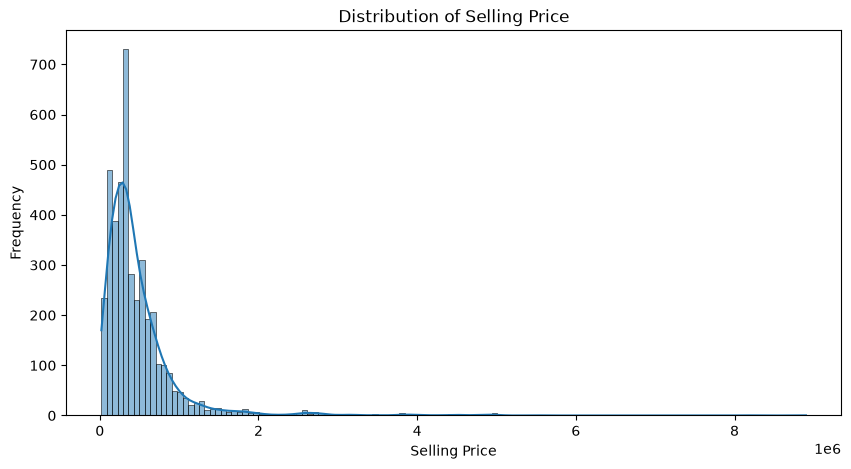

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["selling_price"],
    kde=True
)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

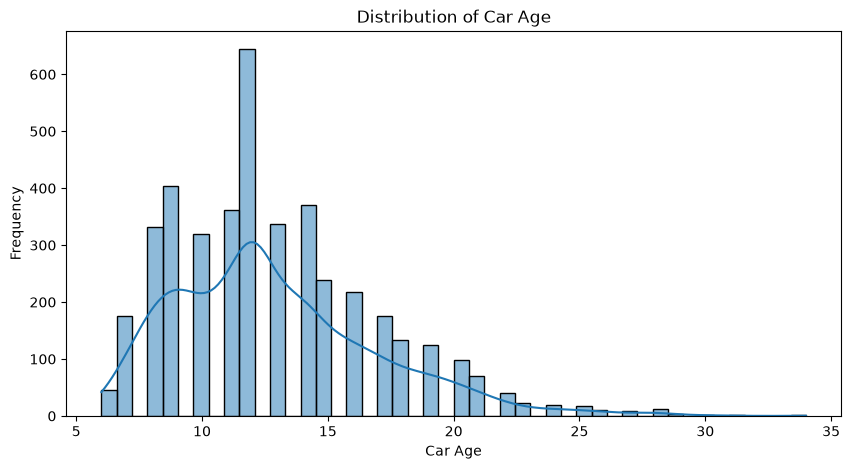

In [44]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["car_age"],
    kde=True
)

plt.title("Distribution of Car Age")
plt.xlabel("Car Age")
plt.ylabel("Frequency")

plt.show()

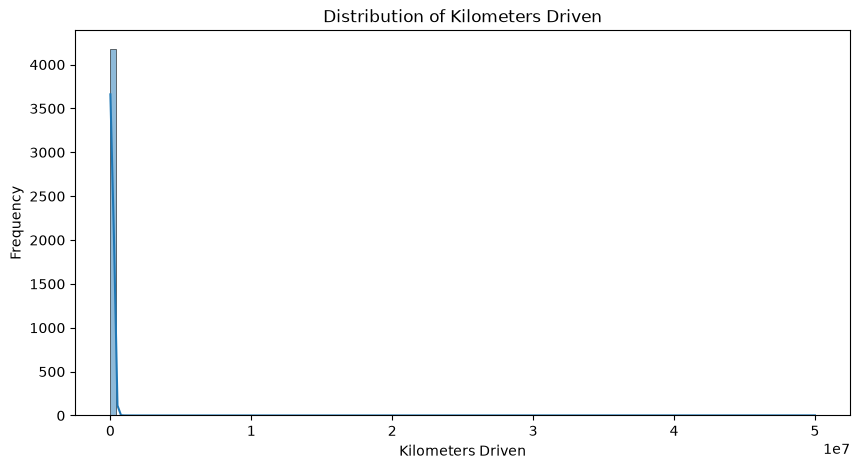

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["km_driven"],
    kde=True
)

plt.title("Distribution of Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Frequency")

plt.show()

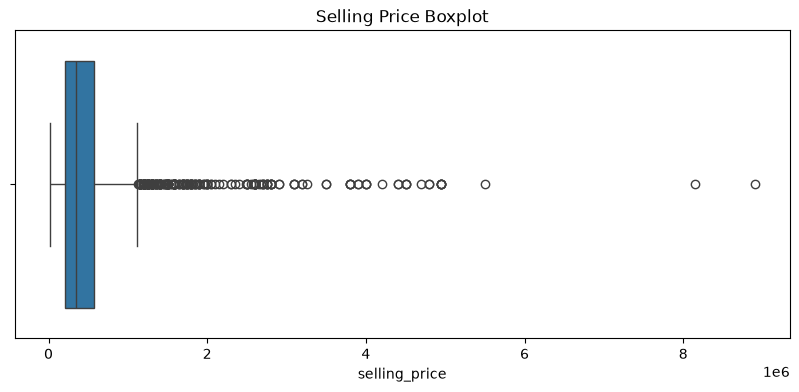

In [46]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_clean["selling_price"]
)

plt.title("Selling Price Boxplot")

plt.show()

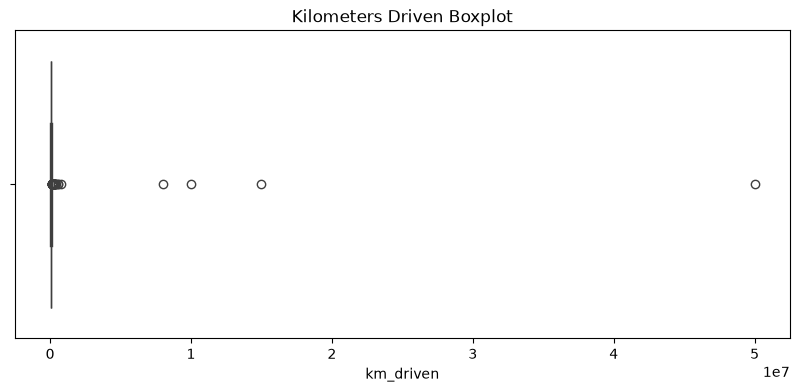

In [47]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_clean["km_driven"]
)

plt.title("Kilometers Driven Boxplot")

plt.show()

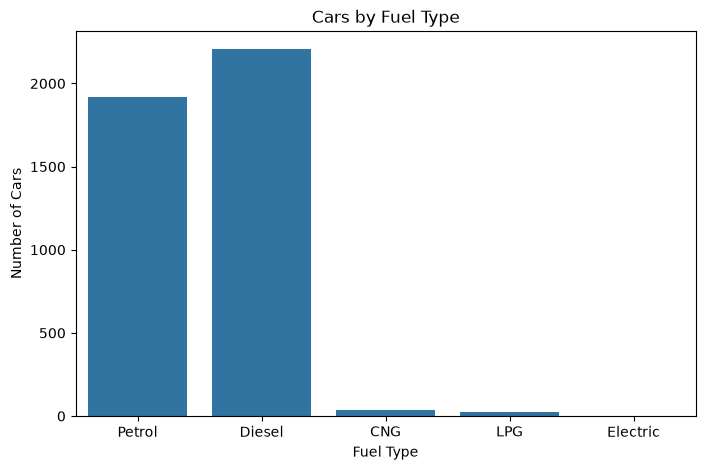

In [48]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="fuel"
)

plt.title("Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

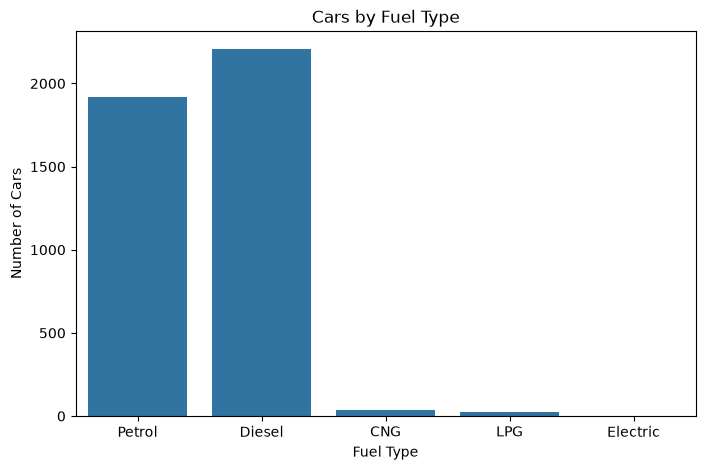

In [49]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="fuel"
)

plt.title("Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

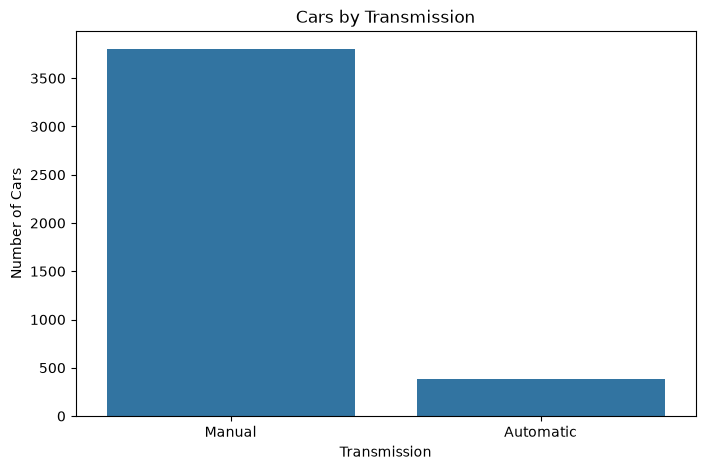

In [50]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="transmission"
)

plt.title("Cars by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")

plt.show()

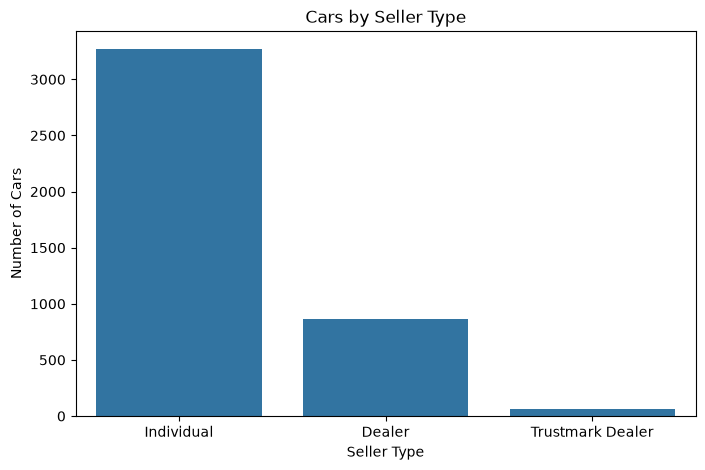

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="seller_type"
)

plt.title("Cars by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Number of Cars")

plt.show()

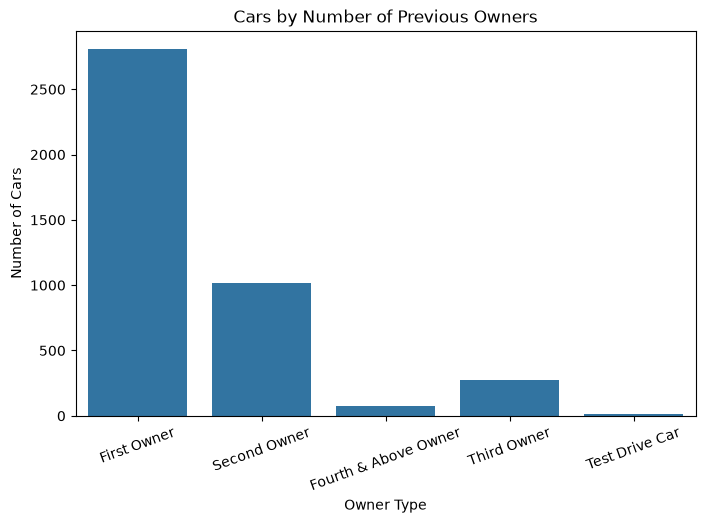

In [52]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="owner"
)

plt.title("Cars by Number of Previous Owners")
plt.xlabel("Owner Type")
plt.ylabel("Number of Cars")

plt.xticks(rotation=20)

plt.show()

## 7. Bivariate Analysis
   - Price vs Age
   - Price vs KM
   - Price vs Fuel
   - Price vs Transmission
   - Price vs Owner
   - Price vs Seller Type
   - Price vs Brand

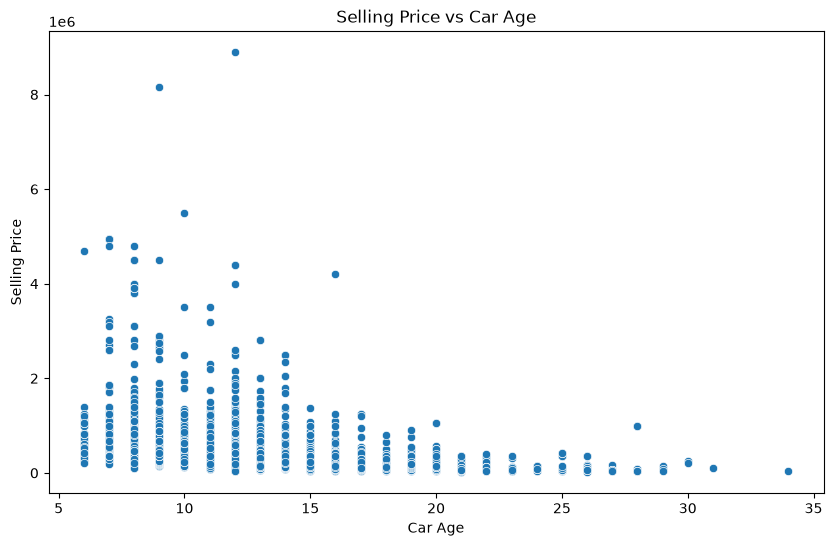

In [53]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="car_age",
    y="selling_price"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

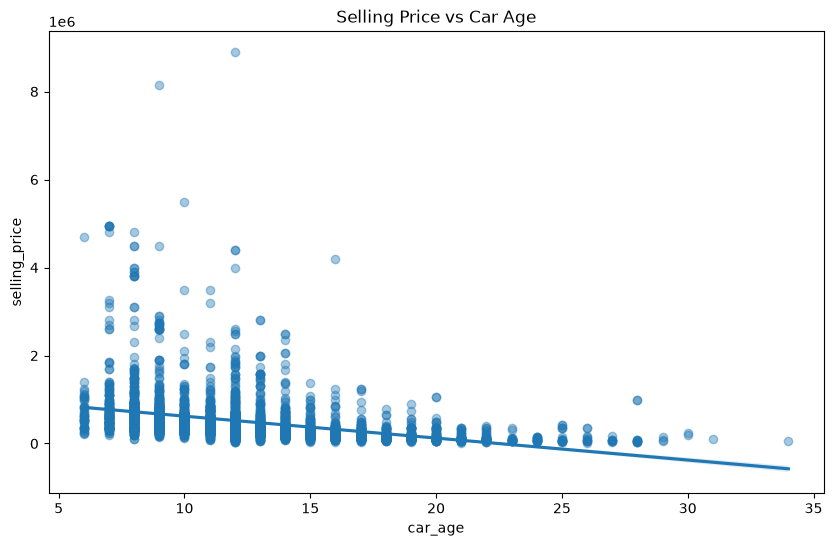

In [54]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x="car_age",
    y="selling_price",
    scatter_kws={"alpha": 0.4}
)

plt.title("Selling Price vs Car Age")

plt.show()

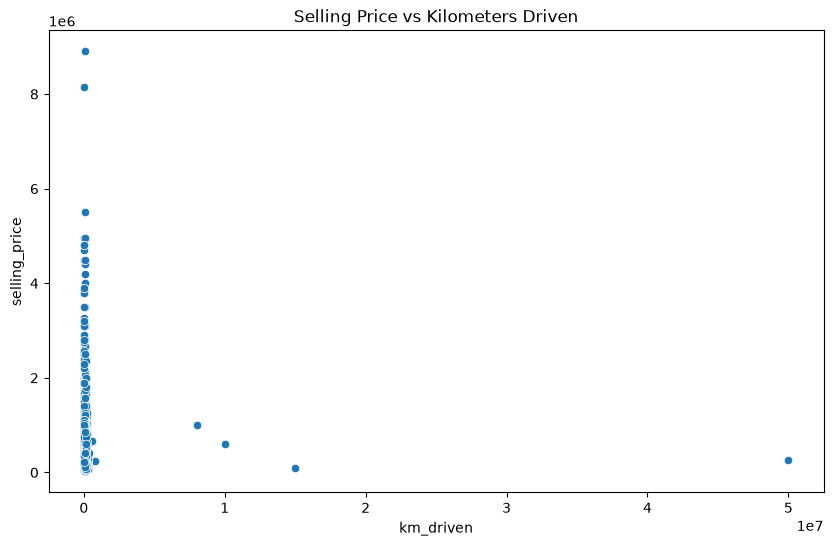

In [55]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="km_driven",
    y="selling_price"
)

plt.title("Selling Price vs Kilometers Driven")

plt.show()

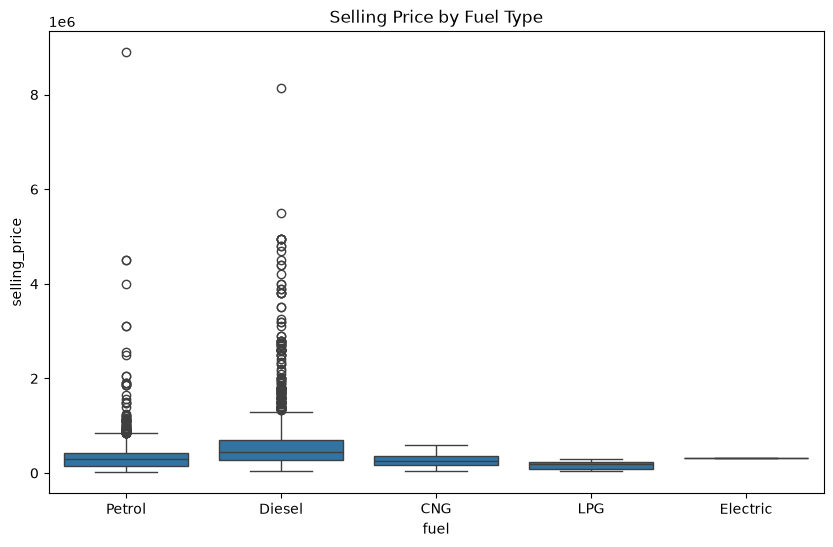

In [56]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")

plt.show()

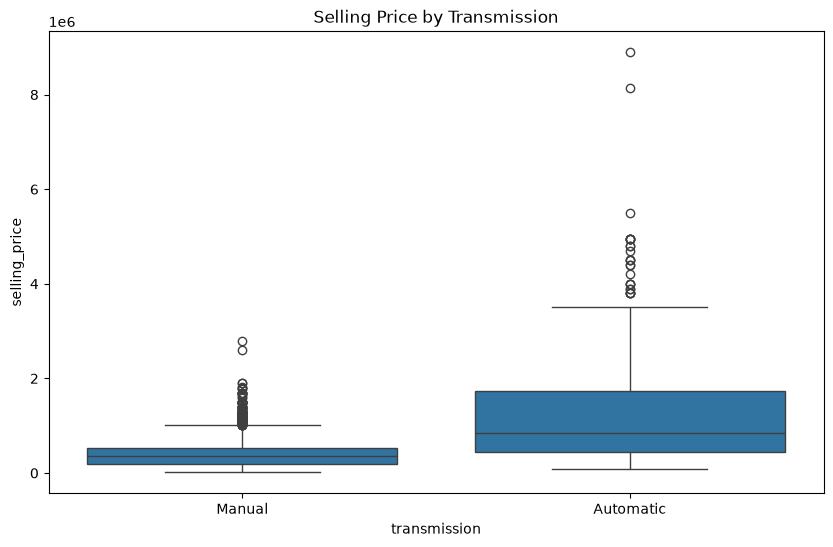

In [57]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="transmission",
    y="selling_price"
)

plt.title("Selling Price by Transmission")

plt.show()

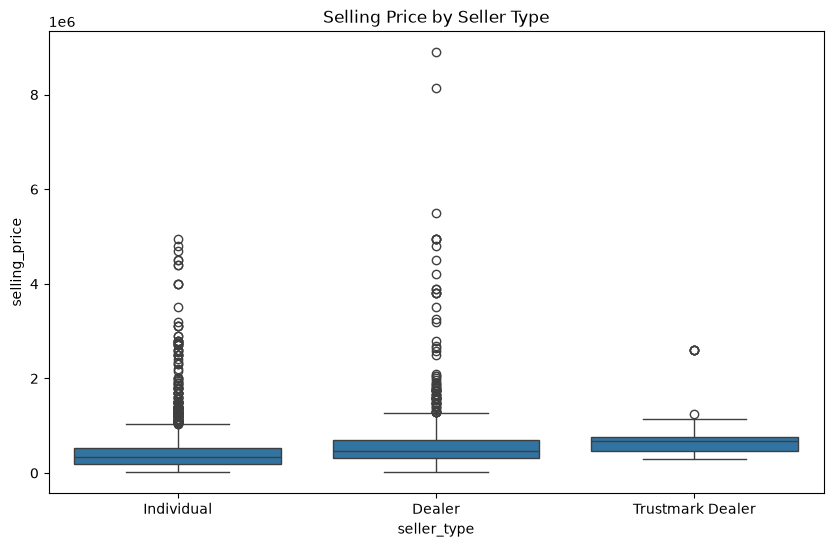

In [58]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="seller_type",
    y="selling_price"
)

plt.title("Selling Price by Seller Type")

plt.show()

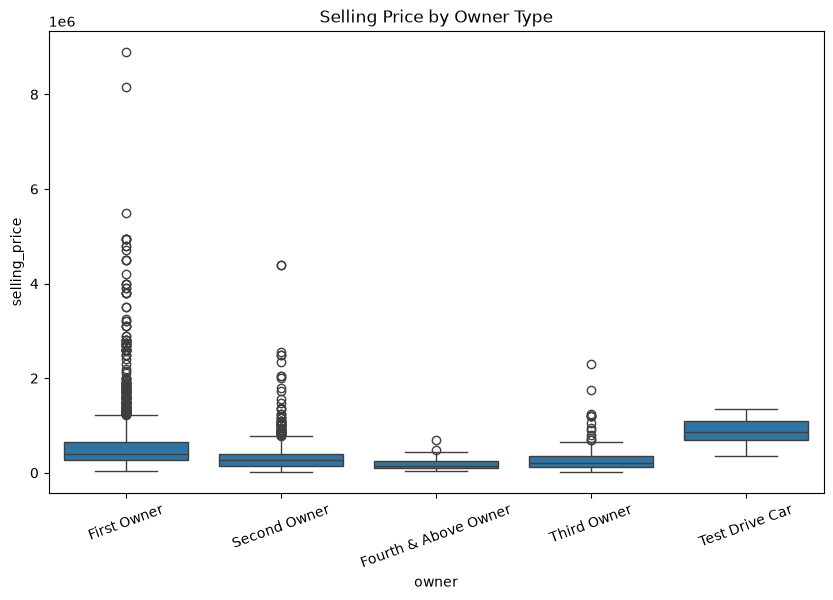

In [59]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="owner",
    y="selling_price"
)

plt.title("Selling Price by Owner Type")

plt.xticks(rotation=20)

plt.show()

In [60]:
top_brands = df_clean["brand"].value_counts().head(10).index

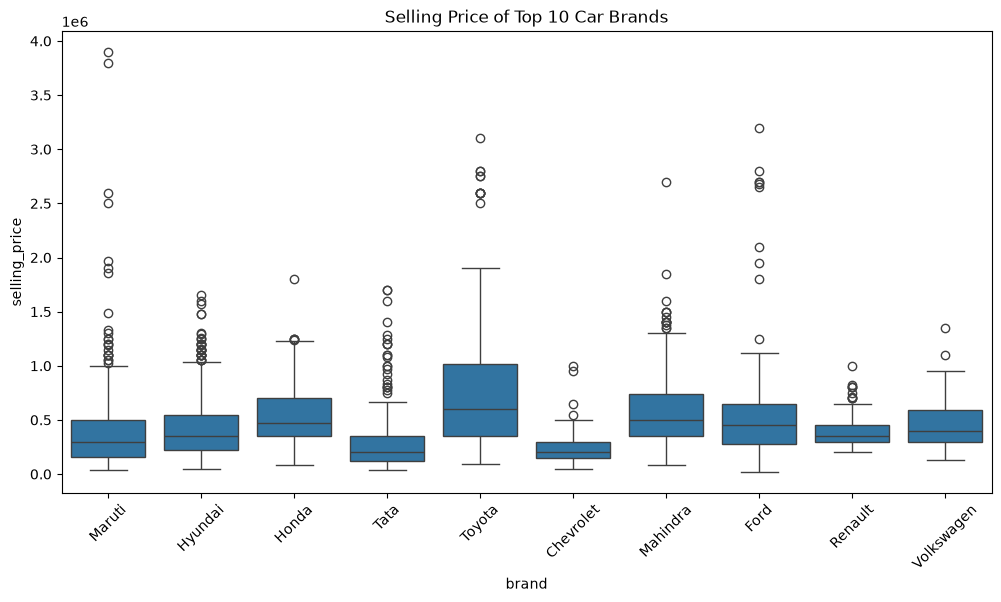

In [61]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean[df_clean["brand"].isin(top_brands)],
    x="brand",
    y="selling_price"
)

plt.title("Selling Price of Top 10 Car Brands")

plt.xticks(rotation=45)

plt.show()

## 8. Multivariate Analysis
   - Correlation Matrix
   - Heatmap
   - Pairplot
   - Multiple Categorical Variables

In [62]:
numerical_columns = [
    "year",
    "selling_price",
    "km_driven",
    "car_age"
]

In [63]:
correlation = df_clean[numerical_columns].corr()

correlation

,year,selling_price,km_driven,car_age
year,1.000000,0.386788,-0.006962,-1.000000
selling_price,0.386788,1.000000,-0.014949,-0.386788
km_driven,-0.006962,-0.014949,1.000000,0.006962
car_age,-1.000000,-0.386788,0.006962,1.000000


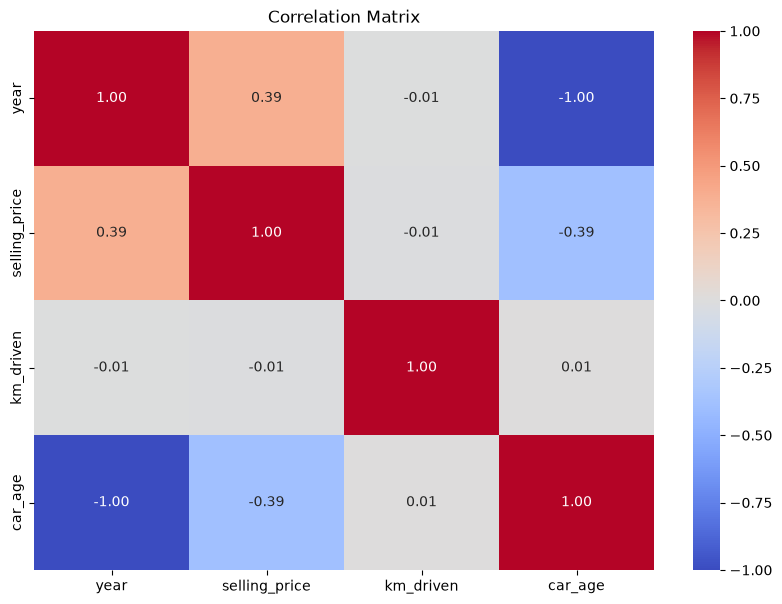

In [64]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

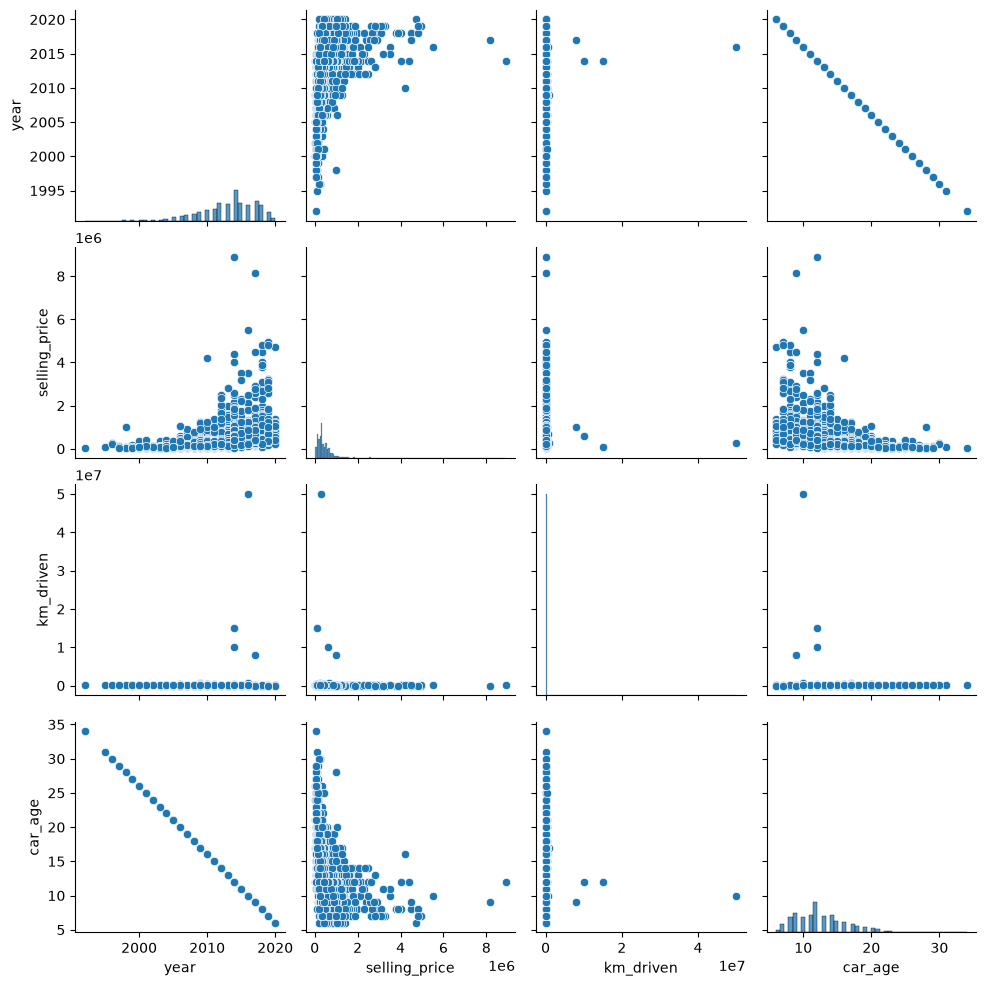

In [65]:
sns.pairplot(
    df_clean[
        ["year", "selling_price", "km_driven", "car_age"]
    ]
)

plt.show()

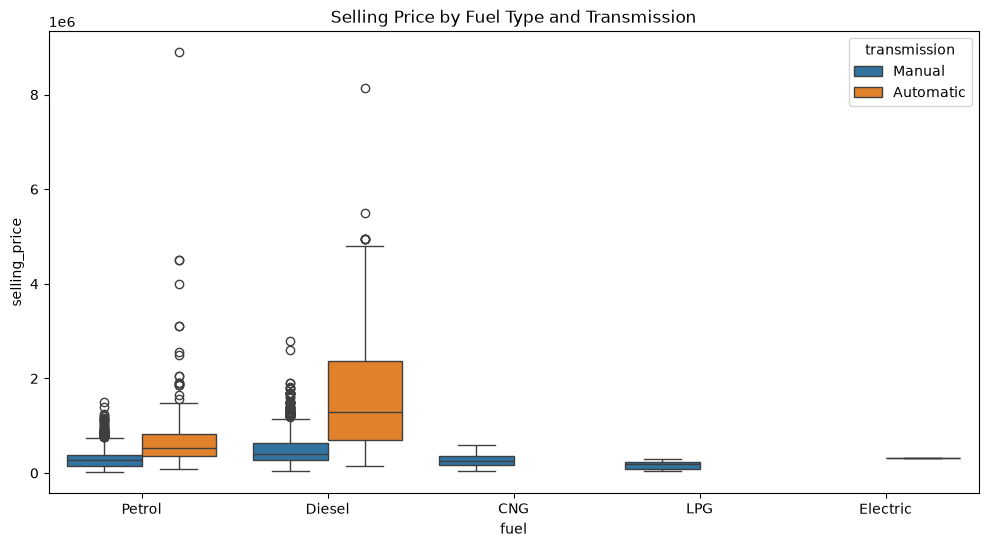

In [66]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x="fuel",
    y="selling_price",
    hue="transmission"
)

plt.title("Selling Price by Fuel Type and Transmission")

plt.show()

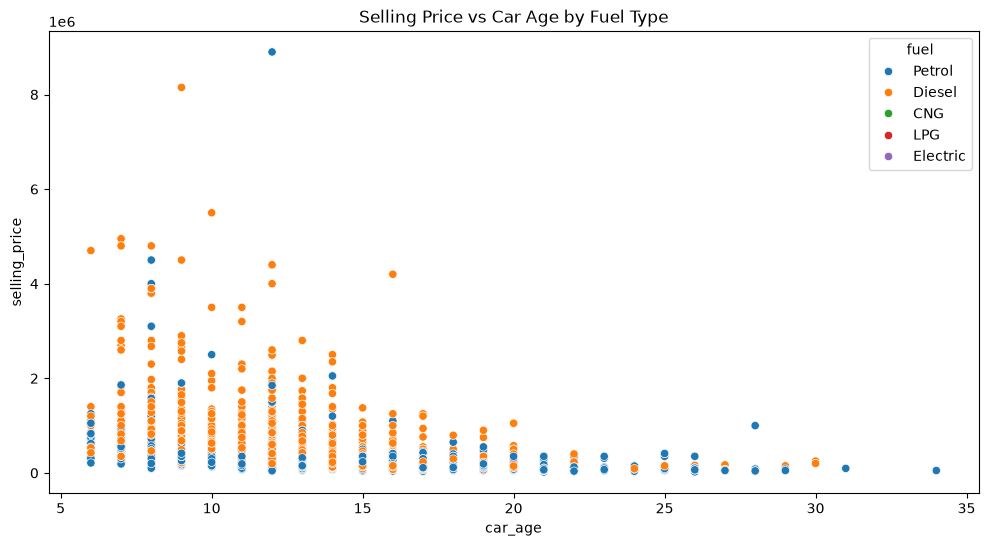

In [67]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_clean,
    x="car_age",
    y="selling_price",
    hue="fuel"
)

plt.title("Selling Price vs Car Age by Fuel Type")

plt.show()

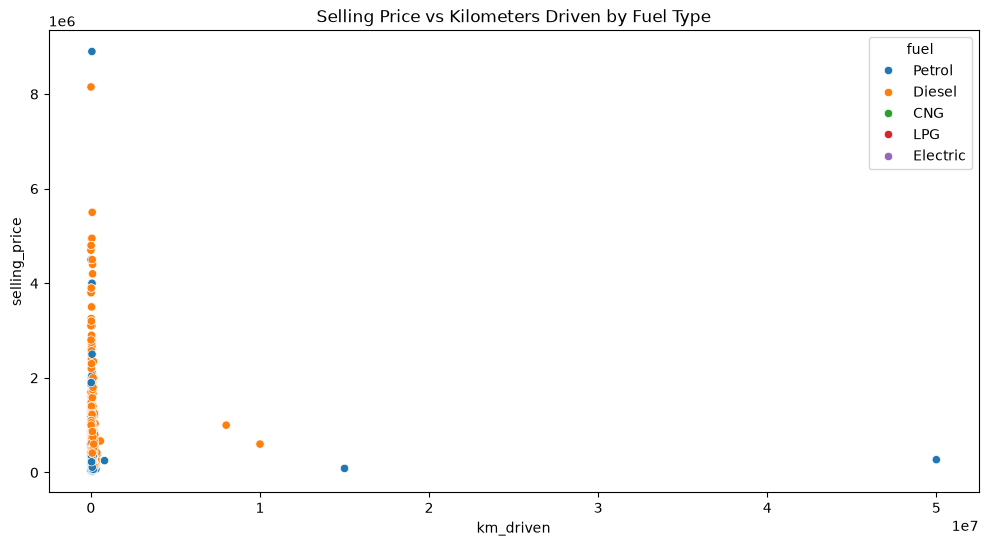

In [68]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_clean,
    x="km_driven",
    y="selling_price",
    hue="fuel"
)

plt.title("Selling Price vs Kilometers Driven by Fuel Type")

plt.show()

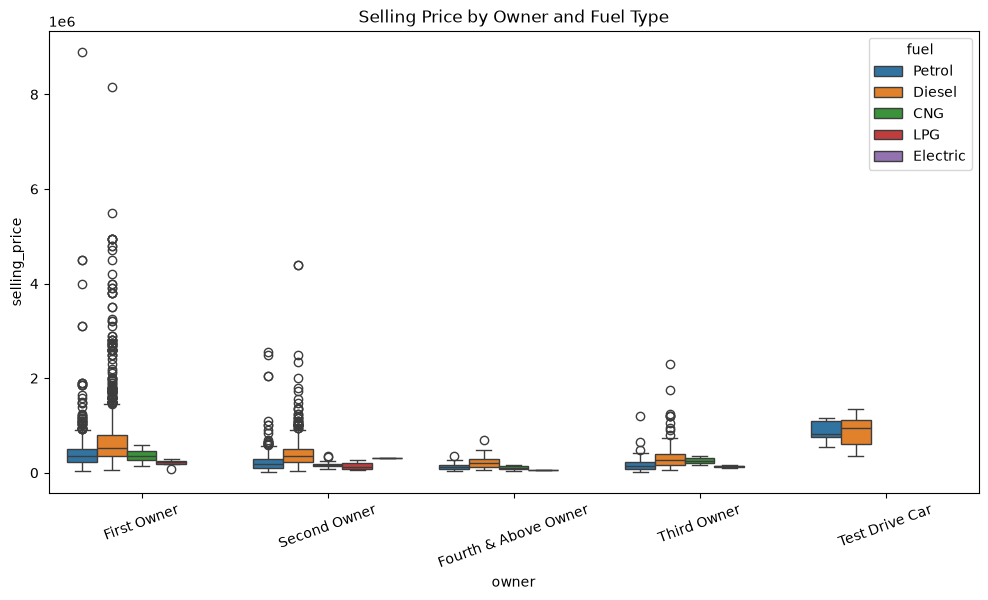

In [69]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x="owner",
    y="selling_price",
    hue="fuel"
)

plt.title("Selling Price by Owner and Fuel Type")

plt.xticks(rotation=20)

plt.show()

In [70]:
df_clean.groupby("fuel")["selling_price"].mean().sort_values(
    ascending=False
)

fuel
Diesel      599080.741497
Petrol      347106.048412
Electric    310000.000000
CNG         278999.921053
LPG         167826.043478
Name: selling_price, dtype: float64

In [71]:
df_clean.groupby("transmission")["selling_price"].mean().sort_values(
    ascending=False
)

transmission
Automatic    1.284697e+06
Manual       3.955748e+05
Name: selling_price, dtype: float64

In [72]:
df_clean.groupby("owner")["selling_price"].mean().sort_values(
    ascending=False
)

owner
Test Drive Car          870882.176471
First Owner             554035.480941
Second Owner            340694.340237
Third Owner             268422.743682
Fourth & Above Owner    174465.712329
Name: selling_price, dtype: float64

In [73]:
df_clean.groupby("seller_type")["selling_price"].mean().sort_values(
    ascending=False
)

seller_type
Trustmark Dealer    808833.333333
Dealer              650701.463415
Individual          426615.179063
Name: selling_price, dtype: float64

In [74]:
df_clean.groupby("brand")["selling_price"].mean().sort_values(
    ascending=False
).head(10)

brand
Land             3.609800e+06
Mercedes-Benz    2.634750e+06
Volvo            2.556250e+06
BMW              2.454242e+06
Jaguar           2.090000e+06
Audi             1.974326e+06
MG               1.825000e+06
Jeep             1.530000e+06
Isuzu            1.500000e+06
Kia              1.300000e+06
Name: selling_price, dtype: float64

In [75]:
df_clean["brand"].value_counts().head(10)

brand
Maruti        1474
Hyundai        716
Tata           326
Mahindra       326
Honda          232
Ford           220
Toyota         184
Chevrolet      167
Renault        122
Volkswagen     101
Name: count, dtype: int64

## 9. Final Insights

### Main Findings

- The dataset contains used-car listings with information about car model, year, price, mileage, fuel type, seller type, transmission, and ownership.
- Most cars are manually transmitted and owned by first-time owners.
- Selling prices show a wide range and contain some outliers.
- Car age and kilometers driven are important factors associated with selling price.
- Newer cars generally tend to have higher selling prices.
- Cars with fewer previous owners tend to have higher average selling prices.
- The dataset contains inconsistencies in categorical values and invalid numerical values, which were handled during data cleaning.

### Business Insights

- Car age can be used as an important factor when estimating a used car's market value.
- Mileage is another useful indicator for understanding vehicle value.
- Transmission type, fuel type, seller type, and ownership history can help segment cars into different pricing groups.

In [76]:
df_clean["selling_price"].mean()

np.float64(478160.3987583572)

In [77]:
df_clean["selling_price"].median()

np.float64(350000.0)

In [78]:
df_clean["car_age"].mean()

np.float64(12.873925501432664)

In [79]:
df_clean["km_driven"].mean()

np.float64(86268.58691499522)

In [80]:
df_clean.nlargest(5, "selling_price")[
    ["name", "year", "selling_price", "km_driven"]
]

,name,year,selling_price,km_driven
3872,Audi RS7 2015-2019 Sportback Performance,2014.0,8900000.0,60000.0
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,2017.0,8150000.0,6500.0
3969,Mercedes-Benz GLS 2016-2020 350d 4MATIC,2016.0,5500000.0,77350.0
555,BMW X5 xDrive 30d xLine,2019.0,4950000.0,30000.0
574,BMW X5 xDrive 30d xLine,2019.0,4950000.0,30000.0


In [81]:
df_clean.nsmallest(5, "selling_price")[
    ["name", "year", "selling_price", "km_driven"]
]

,name,year,selling_price,km_driven
2662,Ford Ikon 1.6 ZXI NXt,2005.0,20000.0,60000.0
2495,Ford Ikon 1.4 ZXi,2000.0,22000.0,42743.0
1832,Tata Nano LX SE,2014.0,35000.0,35000.0
2849,Tata Nano Std BSII,2009.0,35000.0,50000.0
3206,OpelCorsa 1.4 GL,2002.0,35000.0,100000.0


## 10. Final Dataset Check

In [82]:
df_clean.shape

(4188, 12)

In [83]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 4188 entries, 0 to 4339
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                4188 non-null   str    
 1   year                4188 non-null   float64
 2   selling_price       4188 non-null   float64
 3   km_driven           4188 non-null   float64
 4   fuel                4188 non-null   str    
 5   seller_type         4188 non-null   str    
 6   transmission        4188 non-null   str    
 7   owner               4188 non-null   str    
 8   car_age             4188 non-null   float64
 9   brand               4188 non-null   object 
 10  selling_price_lakh  4188 non-null   float64
 11  km_driven_thousand  4188 non-null   float64
dtypes: float64(6), object(1), str(5)
memory usage: 425.3+ KB


In [84]:
df_clean.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
car_age               0
brand                 0
selling_price_lakh    0
km_driven_thousand    0
dtype: int64

In [85]:
df_clean.duplicated().sum()

np.int64(267)

In [86]:
df_clean.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand,selling_price_lakh,km_driven_thousand
0,Maruti 800 AC,2007.0,350000.0,70000.0,Petrol,Individual,Manual,First Owner,19.0,Maruti,3.50,70.0
1,Maruti Wagon R LXI Minor,2014.0,135000.0,50000.0,Petrol,Individual,Manual,First Owner,12.0,Maruti,1.35,50.0
2,Hyundai Verna 1.6 SX,2012.0,600000.0,100000.0,Diesel,Individual,Manual,First Owner,14.0,Hyundai,6.00,100.0
3,Datsun RediGO T Option,2017.0,250000.0,46000.0,Petrol,Individual,Manual,First Owner,9.0,Datsun,2.50,46.0
4,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Diesel,Individual,Manual,Second Owner,12.0,Honda,4.50,141.0
